<a href="https://colab.research.google.com/github/IrisCheon/Py-Practices/blob/main/Toxic_Comment_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toxic Comment Classification and Error Analysis

This project analyses toxic comment classification as a machine learning task.

The analysis includes:
- label distribution
- baseline model evaluation
- confusion matrix
- threshold analysis
- subtype-level recall comparision

캐글 Jigsaw Toxic Comment 데이터셋을 이용한 classification 연습

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("julian3833/jigsaw-toxic-comment-classification-challenge")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jigsaw-toxic-comment-classification-challenge' dataset.
Path to dataset files: /kaggle/input/jigsaw-toxic-comment-classification-challenge


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
print(path)
print(os.listdir(path))
train_path = os.path.join(path, 'train.csv')
df = pd.read_csv(train_path)
df.head()

/kaggle/input/jigsaw-toxic-comment-classification-challenge
['sample_submission.csv', 'test_labels.csv', 'train.csv', 'test.csv']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


# ■ 데이터 확인

In [5]:
df.shape

(159571, 8)

In [6]:
df.info

<bound method DataFrame.info of                       id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2       000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4       0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
...                  ...                                                ...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159569  fff125370e4aaaf3  And it looks like it was actually you who put ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insult  identity_hate  
0           0             0        0       0       0              0  
1           0             0        0       0       0              0  
2           0             0        0       0       0              0  
3           0             0        0       0       0              0  
4           0             0        0       0       0              0  
...       ...           ...      ...     ...     ...            ...  
159566      0             0        0       0       0              0  
159567      0             0        0       0       0              0  
159568      0             0        0       0       0              0  
159569      0             0        0       0       0              0  
159570      0             0        0       0       0              0  

[159571 rows x 8 columns]>

In [7]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [8]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df['identity_hate'].value_counts()

,count
identity_hate,
0,158166
1,1405


In [10]:
df['toxic'].value_counts()

,count
toxic,
0,144277
1,15294


In [11]:
df['severe_toxic'].value_counts()

,count
severe_toxic,
0,157976
1,1595


# ■ 간단한 요약

In [12]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat','insult', 'identity_hate']

label_summary = pd.DataFrame({
    "flagged_count" : df[label_cols].sum(),
    "flagged_percentage" : (df[label_cols].mean() *100).round(2)
    }).sort_values("flagged_count", ascending=False)

label_summary

,flagged_count,flagged_percentage
toxic,15294,9.58
obscene,8449,5.29
insult,7877,4.94
severe_toxic,1595,1.00
identity_hate,1405,0.88
threat,478,0.30


In [13]:
df["is_toxic"] = df[label_cols].max(axis=1)
df["is_toxic"].value_counts()

,count
is_toxic,
0,143346
1,16225


In [14]:
df["comment_length"] = df["comment_text"].str.len()

In [15]:
df.groupby("is_toxic")["comment_length"].describe()

,count,mean,std,min,25%,50%,75%,max
is_toxic,,,,,,,,
0,143346.0,404.347174,586.503447,6.0,102.0,216.0,452.0,5000.0
1,16225.0,303.304037,619.402896,8.0,61.0,128.0,283.0,5000.0


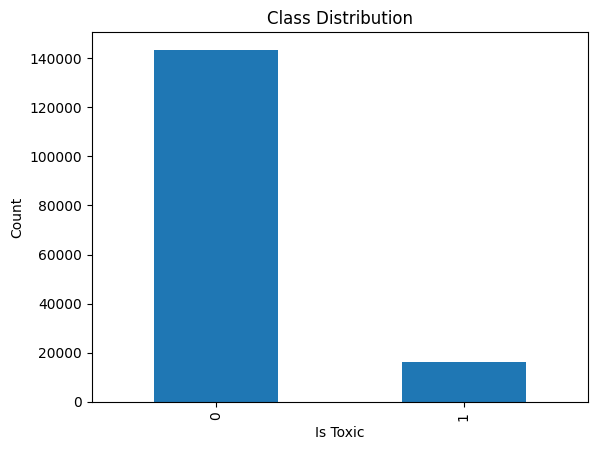

In [16]:
df["is_toxic"].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Is Toxic")
plt.ylabel("Count")
plt.show()

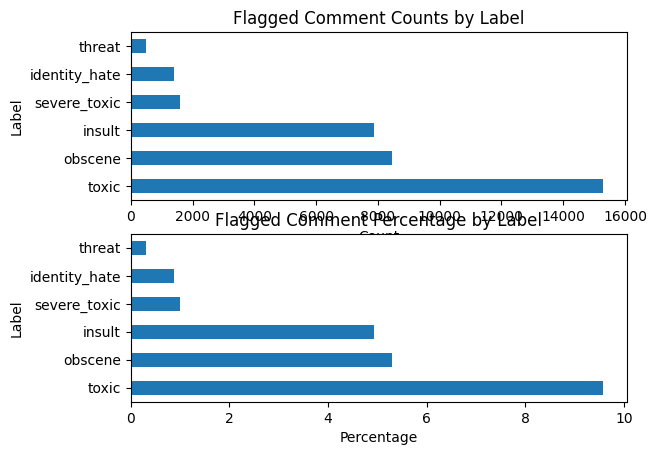

In [17]:
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)

label_summary["flagged_count"].plot(kind='barh', ax=ax1)
ax1.set_title("Flagged Comment Counts by Label")
ax1.set_xlabel("Count")
ax1.set_ylabel("Label")

label_summary["flagged_percentage"].plot(kind="barh", ax=ax2)
ax2.set_title("Flagged Comment Percentage by Label")
ax2.set_xlabel("Percentage")
ax2.set_ylabel("Label")

plt.show()

# ■ Train / Test Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df["comment_text"]  # Data
y = df["is_toxic"]      # Target

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state=42, stratify = y
    )

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [22]:
model = Pipeline([
        ("tfidf", TfidfVectorizer(  # 텍스트를 벡터로
            max_features = 50000,
            ngram_range = (1, 2),
            stop_words = 'english'
        )),
        ("clf", LogisticRegression(
            max_iter = 1000,
            class_weight = 'balanced'
        ))
])

In [23]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
print(classification_report(y_test, y_pred))

# precision : (1기준) 모델이 toxic이라고 한 것 중 실제로 toxic인 비율
    # recall : (1기준) 실제 toxic 중 모델이 toxic이라고 맞춘 비율
# recall 0.95 : 실제 toxic중 85%를 잡아냄
# precision 0.67 : 모델이 toxic이라고 판단한 댓글 중 33%는 non-toxic

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     28670
           1       0.67      0.85      0.75      3245

    accuracy                           0.94     31915
   macro avg       0.83      0.90      0.86     31915
weighted avg       0.95      0.94      0.94     31915



In [27]:
cm = confusion_matrix(y_test, y_pred)
cm

# (TN) 실제0 예측0 / (FP) 실제0 예측1
# (FN) 실제1 예측0 / (TP) 실제1 예측1
# FP가 상대적으로 높음 > 실제로는 정상댓글인데 toxic으로 판단하는 비율이 높음

array([[27314,  1356],
       [  495,  2750]])

In [28]:
import seaborn as sns

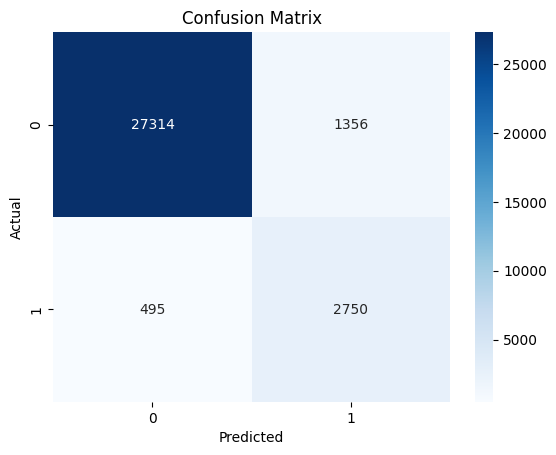

In [29]:
sns.heatmap(cm, annot=True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ■ 결과데이터 확인

In [30]:
# 결과 데이터프레임
results = pd.DataFrame({
    "comment_text" : X_test,
    "actual" : y_test,
    "predicted" : y_pred
})

results.head()

,comment_text,actual,predicted
63958,"""\n\nThanks for helping the plot on Once Upon ...",0,0
11723,There is nothing more ambiguous in logic than ...,0,0
18282,"Go to Hell, fatso \n\nHey, Dickwad! If you ign...",1,1
145258,"""==added Justice and Development Party==\nTurk...",0,0
152834,HI\n\nI added the links and the incidents. I t...,0,0


In [36]:
false_positives = results[
    (results["actual"]==0) & (results["predicted"]==1)]

false_positives.head()

,comment_text,actual,predicted
122245,Parasite Pig \n\nWith the recent death of the ...,0,1
90649,It WASN'T nonsense it was TRUEEEE,0,1
51206,"""\n\n Possible Troll \n\nWhy is the word """"MON...",0,1
124352,"He trolls, edit wars and make personal attacks...",0,1
8325,"""\n\n Gregalton, You're Still A Douchebag, Sig...",0,1


In [33]:
false_negatives = results[
    (results["actual"]==1) & (results["predicted"]==0)
]

false_negatives.head()

,comment_text,actual,predicted
151845,Oppose Iset? Crazy.,1,0
121882,(unless they relate to my hatred of Arabs),1,0
503,I don't care what you say here. I don't believ...,1,0
12208,MESSAGE FOR KEITH D - UP YOURS YOU SMEG-SATURA...,1,0
96175,regarding the user GoodDay\n\nthe user GoodDay...,1,0


In [37]:
pd.set_option("display.max_colwidth",300)
false_positives["comment_text"].sample(10, random_state=42)

,comment_text
73505,"""\n\n You can not convert from AMR to MOA accuracy. \nYeah! And those who can convert are called morons, like guys from amsaa . Only wikipedia users who didnt read any basics in external ballictics have true knowledge. \n\nTo note, """"converting from AMR to MOA accuracy"""" is sign of ignorance. It..."
124857,"I think That ^ ^ ^ \n\nI think that I am going to sue you for being mean to me. I'll get my llawer, and you can get yours! lets see who wins in that fight. Ha!\n\nLove Ya - xxxx"
76143,"""\n\nOH PLEASE PLEASE PLEASE DON""""T DO THIS WHY MOM WHY ??????$? HEEEEELP EMMEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE"""
133882,Haha! Fair enough guys! Please let me know how it should be cut down and I'd be happy to do it otherwise you guys can. Cheers!
59034,I suggest that you grow up. Fatuorum
95276,CAN I ASK WHY THIS 'C. FRED' DUDE IS ALL OVER BABY GIRL'S ARTICLE LIKE IF HE'S A FAN???????
33876,""":::::::Err, I don't see a policy that requires Wikipedia to include information that is demonstrably false. I don't care whether you call it syntheses, connecting the dots, or jumping to conclusion, but to claim that someone confessed to something that they in fact, did not, is just wrong and ..."
92350,"""We do not edit Wikipedia to makeup lies about """"abiogensis did it"""" """
76054,"Anti American \n\nYour edits (and your views / opinions in generaly) are anti American. Anti Americanism is wrong because it involes the hate of Americans (over 300 million people) and the hate of the United States (a country, it seems stupid to me to hate a country). Anti Americanism is ignoran..."
94898,Stop \n\nThe Dana Jacobson has accurate info. Stop deleting it or else.


In [38]:
false_negatives["comment_text"].sample(10, random_state=42)

,comment_text
90756,"""I AM the YuccaMeister and when you quit bloviating and foaming at the mouth and read what i wrote - i suggested a disambugation page or link, to my paragraph about what is in fact a popular and famous party drink, punch WITH THE VERY SAME NAME ... """"Yucca FLats"""" , etc.\nand all that meets ever..."
76785,"Is this the same loser that got booted off of the reality show 'America's Got Talent' for doing nothing but bouncing around half naked screeching a violin and moaning in a terrible falsetto?? If it is, the article should mention that. Millions saw that while only a handful saw the 'Academy Awa..."
35966,"""\n\n Are you retarded or what?? \n\nSo what you want? \nYou think PSP Wiki is have trusted sources? Its copy of Wikipedia and users are adding information not Sony. \nIn PSP Wiki is written: The latest reported firmware version shipping pre-installed on new PSPs is 5.50 (confirmed by a few pe..."
37722,Dear anonymus user/or ' sockpuppet!\nI do not have a mood with you to argue. Look for new friends for yourself\nthere: or .\n (talk • contribs)
112084,"""List of hoolie firms // Denmark ==\nHello. Removing mentions of firms such as Southside United (one of the original firms in Denmark) that actually is mentioned in the source, albeit misspelled """"South Side United"""" by some scummy journalist cunt who's research probably was two coppers and a go..."
18431,"listen you spineless twirp, i have a navy cross and a bullet stuck in my leg, dont you tell me i am not in the military. and by the way, I could have you prosecuted federally for a bout 2 maybe more charges, not to mention a law suit from 50 angry Navy SEALs in Norfolk looks good in our favor. y..."
79964,LMAO your a male nurse
23296,"2006 (UTC)\n\nWho the hell are you to tell me what I am? Libertarians aren't blindly pro-choice, regardless of what your opinion on the matter is. (Talk) 16:06, 1 December"
104453,"""\nYou are by far the most unhelpful, ungracious administrator I have ever had to deal with. You're incompetence is displayed in every encounter we have. Oh, and I'm quite familar with WP:NPA, which you resort to citing whenever you don't get your way. For other administrators who wish to be hel..."
72244,"'Don't other people wonder why we are hemorrhaging editors, and new people aren't joining? \n\nTINK,ABUSIVWMF!!"


# ■ Threshold별 FP, FN 비교

In [39]:
y_proba = model.predict_proba(X_test)[:,1]
# X_test의 각 댓글이 toxic일 확률(전체 행, 두번째 열(toxic))을 가져오기

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [41]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results=[]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        "threshold" : t,
        "precision" : precision_score(y_test, y_pred_t),
        "recall" : recall_score(y_test, y_pred_t),
        "f1" : f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

# threshold가 낮으면 모델이 toxic이라고 한 것중 toxic이 아닌 댓글이 많음(precision) FP
# 그러나 전체 댓글 중 toxic은 거의 잡아냄(recall)

,threshold,precision,recall,f1
0,0.3,0.474843,0.930663,0.628839
1,0.4,0.576501,0.890601,0.699927
2,0.5,0.669752,0.847458,0.748198
3,0.6,0.741345,0.798459,0.768843
4,0.7,0.814777,0.744222,0.777903


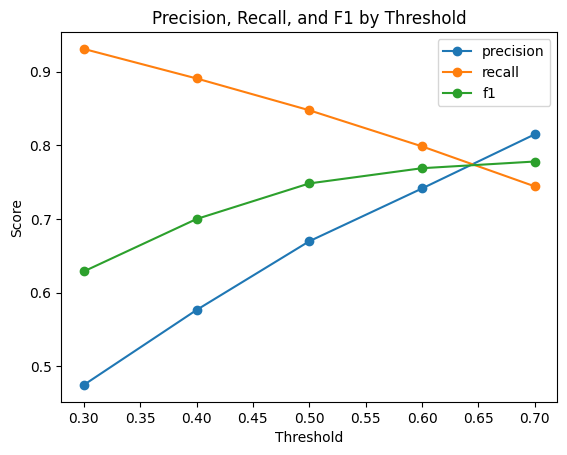

In [43]:
threshold_df.plot(x='threshold', y = ["precision", "recall", "f1"], marker="o")
plt.title("Precision, Recall, and F1 by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.show()

# ■ toxic 정도별 recall 비교

In [45]:
results["severe_toxic"] = df.loc[X_test.index, "severe_toxic"]
results["toxic"] = df.loc[X_test.index, "toxic"]
    # train/test split해도 원본 index는 유지됨

results.head()

,comment_text,actual,predicted,severe_toxic,toxic
63958,"""\n\nThanks for helping the plot on Once Upon a Time in the West - one of my all time favorites - well done """"Expecting you?"""" Contribs """,0,0,0,0
11723,"There is nothing more ambiguous in logic than Evolution. Have you guys upgraded your knowledge and Science, to the latest available publications ? Because all this that you are using to explain ambiguous, sounds a bit weak in convincing capability,\nto anybody with any capacity to determine fact...",0,0,0,0
18282,"Go to Hell, fatso \n\nHey, Dickwad! If you ignore me, I'll poke a hole in you and release all the fat! I WILL NOT hesitate to roast you in an oven like the little piggy you are! Unblock everyone you've blocked or suffer the consequences!!!",1,1,1,1
145258,"""==added Justice and Development Party==\nTurkey's AKP was added to the list due to the fact that """"social conservatism"""" being listed as main ideology of AKP in the AKP Justice and Development Party English Wikipedia Page.\n\n""",0,0,0,0
152834,"HI\n\nI added the links and the incidents. I think its constructive. please refute the links first, then undo it.",0,0,0,0


In [46]:
severe_subset = results[results["severe_toxic"]==1]
severe_recall = (
    severe_subset["predicted"] == 1
).mean()

print(severe_recall)

0.9901639344262295


In [48]:
toxic_subset = results[results["toxic"]==1]
toxic_recall = (
    toxic_subset["predicted"]==1
).mean()

print(toxic_recall)

0.8568614576493763


In [ ]:
# severe toxic : 0.9901639344262295
# general toxic : 0.8568614576493763

In [50]:
cm_severe = confusion_matrix(
    results["severe_toxic"],
    results["predicted"]
)

print(cm_severe)

[[27806  3804]
 [    3   302]]


In [55]:
label_eval = {}

for label_col_name in label_cols:
    if label_col_name not in results.columns:
        results[label_col_name] = df.loc[X_test.index, label_col_name]

for label in label_cols:
    subset = results[results[label] == 1]
    recall = (subset["predicted"]==1).mean()
    count = len(subset)
    label_eval[label] = {
        "count" : count,
        "recall" : recall
    }      # 딕셔너리에 값 저장하기

label_eval_df = pd.DataFrame.from_dict(
    label_eval,
    orient = 'index'
)

label_eval_df.sort_values("recall", ascending=False)

,count,recall
severe_toxic,305,0.990164
obscene,1662,0.951865
insult,1576,0.941624
identity_hate,259,0.903475
threat,98,0.867347
toxic,3046,0.856861
